In [8]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules, 
    volcano_plot_region_within_group
)
import scanpy as sc
import numpy as np

import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import scanpy as sc
from itertools import combinations
from scipy import sparse

In [9]:
ad = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [13]:
import numpy as np
import pandas as pd
import scanpy as sc
from itertools import product
from scipy import sparse

def run_de(
    adata,
    groupby="treatment",
    contrasts=(("PBS","WT"), ("BRICHOS","WT"), ("BRICHOS","PBS")),
    method="wilcoxon",          # or "t-test_overestim_var", "t-test", "logreg"
    layer=None,                 # None => use .X
    use_raw=False,
    lfc_cap=10.0
):
    out = []
    for g, r in contrasts:
        sc.tl.rank_genes_groups(
            adata, groupby=groupby, groups=[g], reference=r,
            method=method, layer=layer, use_raw=use_raw
        )
        df = sc.get.rank_genes_groups_df(adata, group=g).rename(
            columns={"names":"gene","pvals":"pval","pvals_adj":"padj","logfoldchanges":"log2fc"}
        )

        # Ensure standard columns exist
        needed = ["gene","log2fc","pval","padj","scores","pts","pts_rest"]
        for col in needed:
            if col not in df.columns:
                df[col] = np.nan

        # Fallback log2fc if Scanpy didn't compute it
        if not np.isfinite(df["log2fc"]).any():
            X = adata.layers.get(layer, adata.X) if layer is not None else adata.X
            if sparse.issparse(X): X = X.toarray()
            mask_g = (adata.obs[groupby].astype(str).values == str(g))
            mask_r = (adata.obs[groupby].astype(str).values == str(r))
            eps = 1e-9
            m_g = X[mask_g].mean(axis=0); m_r = X[mask_r].mean(axis=0)
            df = df.merge(pd.Series(np.log2((m_g+eps)/(m_r+eps)),
                                    index=adata.var_names, name="lfc_fallback"),
                          left_on="gene", right_index=True, how="left")
            df["log2fc"] = df["lfc_fallback"]

        df["log2fc"] = df["log2fc"].clip(-lfc_cap, lfc_cap)
        df["contrast"] = f"{g}_vs_{r}"
        df["groupby"]  = groupby

        keep = ["contrast","groupby","gene","log2fc","pval","padj","scores","pts","pts_rest"]
        out.append(df[keep])

    return pd.concat(out, ignore_index=True)

In [14]:
# pip install gprofiler-official
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

ENDOCYTOSIS_KEYWORDS = [
    "endocyt", "recycling", "vesicle", "endosome", "phagosome",
    "lysosome", "clathrin", "caveol", "traffick", "internaliz"
]

def run_go_mm(genes, sources=("GO:BP",), user_threshold=0.05):
    if len(genes) == 0:
        return pd.DataFrame()
    enr = gp.profile(
        organism="mmusculus",
        sources=list(sources),
        user_threshold=user_threshold,
        significance_threshold_method="fdr",
        query=genes
    )
    # tidy
    if enr.empty:
        return enr
    cols = ["source","native","name","p_value","term_size","intersection","precision","recall"]
    keep = [c for c in cols if c in enr.columns]
    return enr[keep].rename(columns={"native":"term_id","name":"term","p_value":"pval"})

def filter_endocytosis_terms(go_df, keywords=ENDOCYTOSIS_KEYWORDS):
    if go_df is None or len(go_df)==0: 
        return go_df
    patt = "|".join(keywords)
    return go_df[go_df["term"].str.contains(patt, case=False, regex=True)].copy()

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def bubble_go(go_df, title=None, top_n=15):
    if go_df is None or go_df.empty:
        print("No GO terms to plot.")
        return
    df = go_df.sort_values("pval").head(top_n).copy()
    df["neglog10p"] = -np.log10(df["pval"].clip(1e-300, 1))
    df = df.sort_values("neglog10p")
    plt.figure(figsize=(6, 0.4*len(df)+1))
    plt.scatter(df["neglog10p"], np.arange(len(df)), s=40 + 10*df["term_size"]**0.5)
    for i, t in enumerate(df["term"]):
        plt.text(df["neglog10p"].iloc[i]+0.1, i, t, va="center", fontsize=9)
    plt.yticks([])
    plt.xlabel("-log10(FDR)")
    if title: plt.title(title)
    plt.tight_layout()
    plt.show()

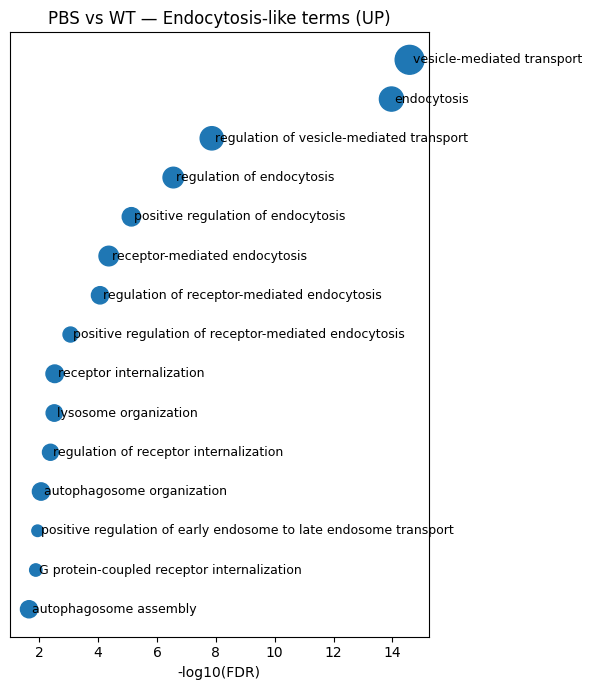

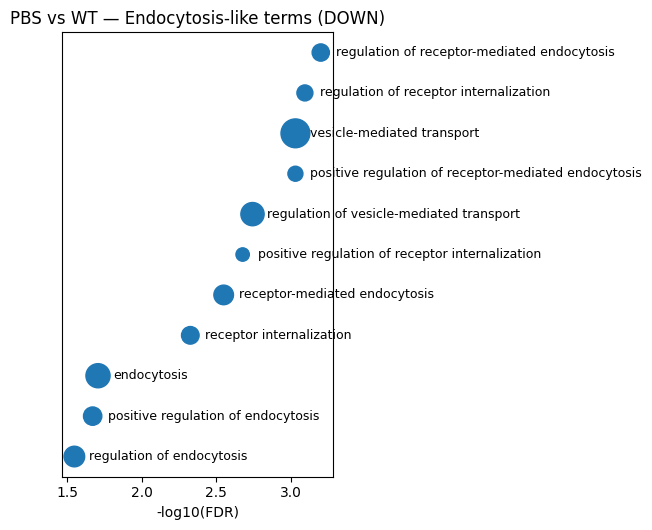

In [16]:
# --- BULK (all spots/cells)
contrasts = [("PBS","WT"), ("BRICHOS","WT"), ("BRICHOS","PBS")]
de_bulk = run_de(ad, groupby="treatment", contrasts=contrasts, method="t-test", layer = None)

de_bulk.to_csv("de_bulk_treatment.csv", index=False)

# gene lists (sig up/down) per contrast
def split_sig(de_df, contrast, padj_max=0.05, lfc_min=0.25):
    sub = de_df[de_df["contrast"]==contrast]
    up = sub[(sub["padj"]<=padj_max) & (sub["log2fc"]>=lfc_min)]["gene"].tolist()
    dn = sub[(sub["padj"]<=padj_max) & (sub["log2fc"]<=-lfc_min)]["gene"].tolist()
    return up, dn

# Example: PBS vs WT
up_pbs_wt, dn_pbs_wt = split_sig(de_bulk, "PBS_vs_WT")
go_up = filter_endocytosis_terms(run_go_mm(up_pbs_wt))
go_dn = filter_endocytosis_terms(run_go_mm(dn_pbs_wt))

bubble_go(go_up,  title="PBS vs WT — Endocytosis-like terms (UP)")
bubble_go(go_dn,  title="PBS vs WT — Endocytosis-like terms (DOWN)")


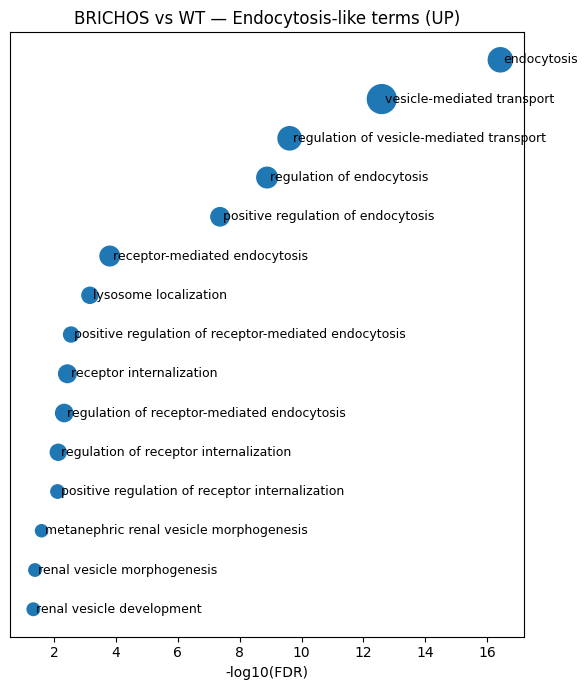

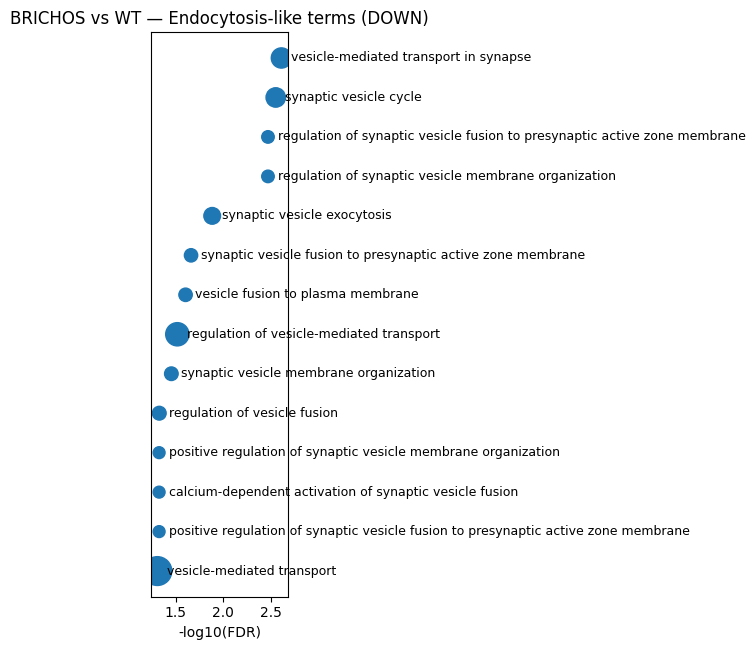

In [18]:

# Example: PBS vs WT
up_pbs_wt, dn_pbs_wt = split_sig(de_bulk, "BRICHOS_vs_WT")
go_up = filter_endocytosis_terms(run_go_mm(up_pbs_wt))
go_dn = filter_endocytosis_terms(run_go_mm(dn_pbs_wt))

bubble_go(go_up,  title="BRICHOS vs WT — Endocytosis-like terms (UP)")
bubble_go(go_dn,  title="BRICHOS vs WT — Endocytosis-like terms (DOWN)")


In [20]:
# pip install gseapy
import numpy as np, pandas as pd
import gseapy as gp

# de_bulk: tidy DF with columns ["gene","log2fc","padj","contrast", ...]
def make_rank(de_df, contrast):
    sub = de_df.query("contrast == @contrast").dropna(subset=["gene","log2fc","padj"]).copy()
    sub["score"] = np.sign(sub["log2fc"]) * (-np.log10(np.clip(sub["padj"], 1e-300, 1)))
    # collapse duplicates by max |score|
    sub = sub.loc[sub.groupby("gene")["score"].apply(lambda s: s.abs().idxmax())]
    ranks = sub.set_index("gene")["score"].sort_values(ascending=False)
    return ranks

contrast = "PBS_vs_WT"  # e.g., "BRICHOS_vs_PBS"
ranks = make_rank(de_bulk, contrast)

# Run preranked GSEA against GO:BP (Enrichr library)
pre_res = gp.prerank(
    rnk=ranks,
    gene_sets="GO_Biological_Process_2023",  # Enrichr set
    processes=4,
    permutation_num=1000,  # increase if you want tighter p-values
    outdir=None, seed=42, min_size=10, max_size=2000
).res2d  # DataFrame

# Keep endocytosis/trafficking flavored terms (optional)
mask = pre_res["Term"].str.contains(
    r"endocyt|recycl|vesicle|endosom|phagosom|lysosom|clathrin|caveol|traffic|internaliz",
    case=False, regex=True
)
pre_res_endocytosis = pre_res[mask].sort_values("FDR q-val")

# View top results
pre_res.head(15)
pre_res_endocytosis.head(15)

2025-09-29 12:13:16,677 [WARNING] Duplicated values found in preranked stats: 9.49% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
202,prerank,Positive Regulation Of Endocytosis (GO:0045807),0.730277,1.463752,0.004505,0.309644,1.0,14/69,7.25%,B2m;Trem2;Mertk;Fcer1g;Cyba;Fcgr2b;Slc11a1;Doc...
13,prerank,Presynaptic Endocytosis (GO:0140238),-0.786208,-1.728941,0.007463,0.315467,0.949,7/26,3.11%,Syt1;Vamp2;Dnm1;Synj1;Sncb;Sncg;Ap2b1
104,prerank,Protein Targeting To Lysosome (GO:0006622),0.839292,1.509799,0.009901,0.326435,1.0,5/22,6.25%,Laptm5;Lamp2;Gnptg;Sorl1;Becn1
348,prerank,Golgi To Lysosome Transport (GO:0090160),0.84326,1.40676,0.036943,0.340936,1.0,2/11,2.25%,Laptm5;Lamp1
5,prerank,Synaptic Vesicle Endocytosis (GO:0048488),-0.753507,-1.788539,0.0,0.345757,0.756,9/35,3.11%,Syt1;Dnajc6;Vamp2;Dnm1;Synj1;Sncb;Snap91;Sncg;...
10,prerank,Synaptic Vesicle Recycling (GO:0036465),-0.740448,-1.741973,0.008264,0.34623,0.926,10/39,3.11%,Syt1;Vamp2;Dnm1;Synj1;Ap3b2;Sncb;Rab3a;Sncg;Gi...
19,prerank,Regulation Of Clathrin-Dependent Endocytosis (...,-0.84128,-1.685135,0.023148,0.374152,0.987,5/14,2.97%,Wasl;Tnk2;Pik3cb;Snap91;Ubqln2
3,prerank,Synaptic Vesicle Exocytosis (GO:0016079),-0.752533,-1.800216,0.0,0.440628,0.703,7/40,1.67%,Syt1;Snph;Vamp2;Cplx2;Snap25;Syt11;Rab3a
590,prerank,Autophagosome Maturation (GO:0097352),0.693466,1.322585,0.09047,0.452492,1.0,8/38,6.96%,Lix1;Vti1b;Lamp2;Vamp8;Chmp3;Uvrag;Becn1;Map1lc3a
687,prerank,"Retrograde Transport, Endosome To Golgi (GO:00...",0.640625,1.296223,0.075991,0.483739,1.0,35/79,22.30%,Vti1b;Snx5;Rab6a;Rnf126;Vti1a;Trim27;Tbc1d10a;...


In [22]:
de_bulk

,contrast,groupby,gene,log2fc,pval,padj,scores,pts,pts_rest
0,PBS_vs_WT,treatment,Cst7,6.735904,0.000000e+00,0.000000e+00,88.694099,NaN,NaN
1,PBS_vs_WT,treatment,Gfap,1.930943,0.000000e+00,0.000000e+00,62.538685,NaN,NaN
2,PBS_vs_WT,treatment,Ccl6,3.374866,0.000000e+00,0.000000e+00,52.072121,NaN,NaN
3,PBS_vs_WT,treatment,Cd74,2.792581,0.000000e+00,0.000000e+00,49.236271,NaN,NaN
4,PBS_vs_WT,treatment,Tyrobp,1.843857,0.000000e+00,0.000000e+00,43.700993,NaN,NaN
...,...,...,...,...,...,...,...,...,...
56248,BRICHOS_vs_PBS,treatment,Ckb,-0.264556,9.517878e-135,1.372844e-131,-25.011263,NaN,NaN
56249,BRICHOS_vs_PBS,treatment,Hcrt,-4.458500,1.401785e-144,2.389533e-141,-25.861214,NaN,NaN
56250,BRICHOS_vs_PBS,treatment,Stmn1,-0.518006,7.911626e-148,1.483509e-144,-26.215679,NaN,NaN
56251,BRICHOS_vs_PBS,treatment,Cox6c,-0.327601,4.856504e-158,1.517738e-154,-27.179558,NaN,NaN


In [23]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

def top_changed_go(de_df, contrast, K=500, fdr=0.05):
    sub = de_df.query("contrast == @contrast").copy()
    if fdr is not None:
        sub = sub[sub["padj"] <= fdr]
    top = sub.reindex(sub["log2fc"].abs().sort_values(ascending=False).index).head(K)
    genes = top["gene"].dropna().tolist()
    if not genes: 
        return pd.DataFrame()
    enr = gp.profile(
        organism="mmusculus",
        sources=["GO:BP"],
        query=genes,
        significance_threshold_method="fdr",
        user_threshold=0.05
    )
    return enr

go_top = top_changed_go(de_bulk, contrast="PBS_vs_WT", K=500, fdr=0.05)

In [24]:
import matplotlib.pyplot as plt, numpy as np

def bubble_go(df, title=None, top_n=15):
    if df is None or df.empty: 
        print("No terms."); return
    # normalize columns across sources
    if "p_value" in df.columns: df = df.rename(columns={"p_value":"pval"})
    if "name" in df.columns: df = df.rename(columns={"name":"Term"})
    df = df.sort_values("pval").head(top_n).copy()
    df["neglog10p"] = -np.log10(np.clip(df["pval"], 1e-300, 1))
    plt.figure(figsize=(6, 0.4*len(df)+1))
    plt.scatter(df["neglog10p"], range(len(df)), s=30 + 8*np.sqrt(df.get("term_size", 25)))
    for i, t in enumerate(df["Term"]):
        plt.text(df["neglog10p"].iloc[i]+0.1, i, t, va="center", fontsize=9)
    plt.yticks([]); plt.xlabel("-log10(FDR)")
    if title: plt.title(title)
    plt.tight_layout(); plt.show()

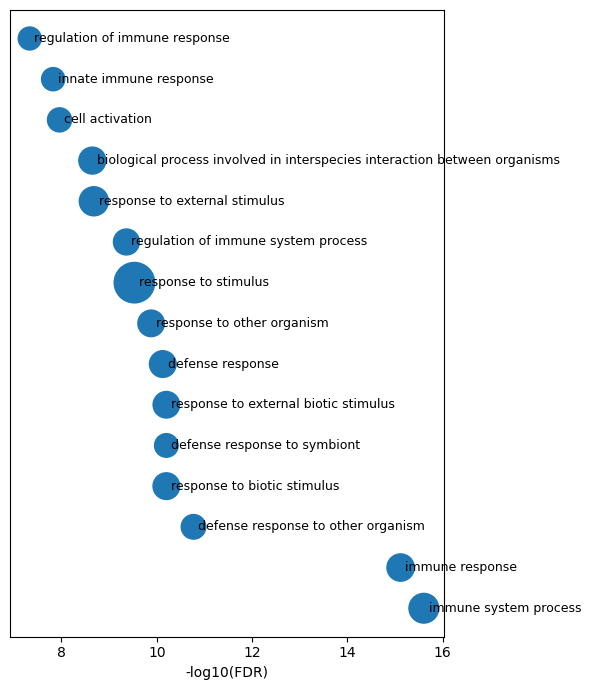

In [25]:
bubble_go(go_top)